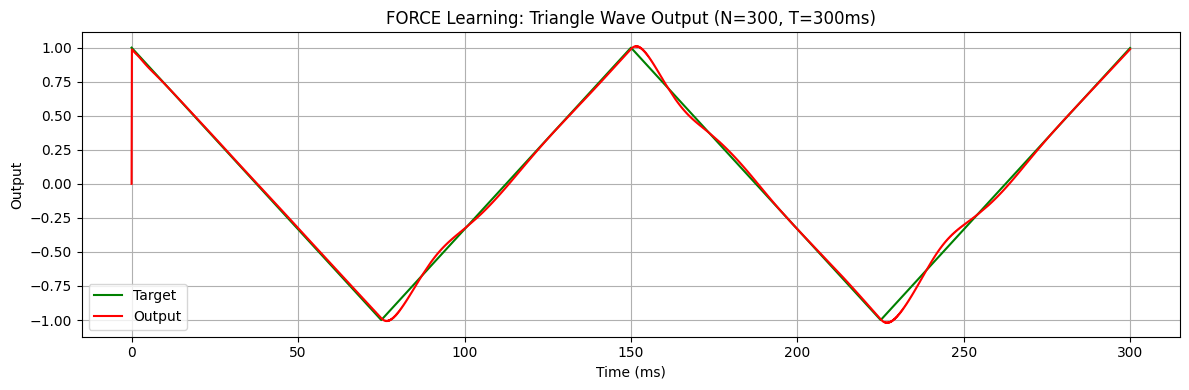

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ========== Hyperparameters ==========

N = 300                 # Number of neurons in the RNN
alpha = 1.0             # Regularization parameter for RLS (acts like learning rate)
tau = 10.0              # Time constant of neurons (in ms)
dt = 0.1                # Time step for numerical integration (in ms)
T = 300                 # Total simulation time (in ms)
steps = int(T / dt)     # Number of time steps
learn_every = 2         # How often to update the output weights

# ========== Define Target Function ==========

def triangle_wave(t, period=150):
    # A triangle wave that oscillates between -1 and 1
    return 2 * np.abs(2 * ((t / period) % 1) - 1) - 1

time = np.arange(0, T, dt)
f_target = triangle_wave(time)  # Our target function over time

# ========== Initialize RNN ==========

scale = 1.5  # Controls how chaotic the network is (try reducing this if output is too noisy)
J = np.random.randn(N, N) * scale / np.sqrt(N)  
# Random recurrent connection matrix, scaled for stability (think: weights between neurons)

w_out = np.zeros(N)  # Output weights: how each neuron contributes to the final output
x = np.random.randn(N)  # Initial state of neurons
r = np.tanh(x)           # Firing rates after applying tanh nonlinearity
z = 0.0                  # Initial output

P = (1.0 / alpha) * np.eye(N)  
# Inverse correlation matrix used in RLS. Starts off as identity matrix scaled by 1/alpha.

z_out = np.zeros(steps)  # To record output over time

# ========== FORCE Learning Loop ==========

for i in range(steps):
    # Step 1: Update neuron state using Euler integration
    dx = dt / tau * (-x + J @ r + w_out * z)  
    # -x is leak, J @ r is recurrent input, w_out * z is feedback from output
    x += dx
    r = np.tanh(x)       # Neuron activations using tanh nonlinearity
    z = w_out @ r        # Network output: weighted sum of neuron activities
    z_out[i] = z         # Store output

    # Step 2: Update output weights every few steps using Recursive Least Squares
    if i % learn_every == 0:
        err = z - f_target[i]     # Difference between current output and target
        Pr = P @ r                # Intermediate term for weight update
        rPr = r @ Pr              # Scalar: r^T * P * r
        c = 1.0 / (1.0 + rPr)     # Learning rate scaling factor
        P -= np.outer(Pr, Pr) * c  # Update P (reduces influence of directions already learned)
        w_out -= err * Pr * c      # Update weights to reduce current error
        # This is the real FORCE learning magic

# ========== Plotting ==========

plt.figure(figsize=(12, 4))
plt.plot(time, f_target, 'g', label='Target')   # Green = triangle wave we want
plt.plot(time, z_out, 'r', label='Output')      # Red = what the RNN actually outputs
plt.title('FORCE Learning: Triangle Wave Output (N=300, T=300ms)')
plt.xlabel('Time (ms)')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()